In [3]:
import numpy as np
import matplotlib.pyplot as plt

In the current model, every individual always imitates the single best demonstrator. But in reality, learners might not always have access to — or even seek out — the best individual. 

Modify demography_model() to add a parameter q representing the probability that a learner imitates the best individual. With probability 1 - q, they instead pick a random individual from the population as their demonstrator.

Run the population-size sweep for q = 1.0, 0.75, 0.5, 0.25 and plot Δz̄ against N. How does relaxing the "copy the best" assumption affect N*? Is the effect stronger for simple or complex skills?

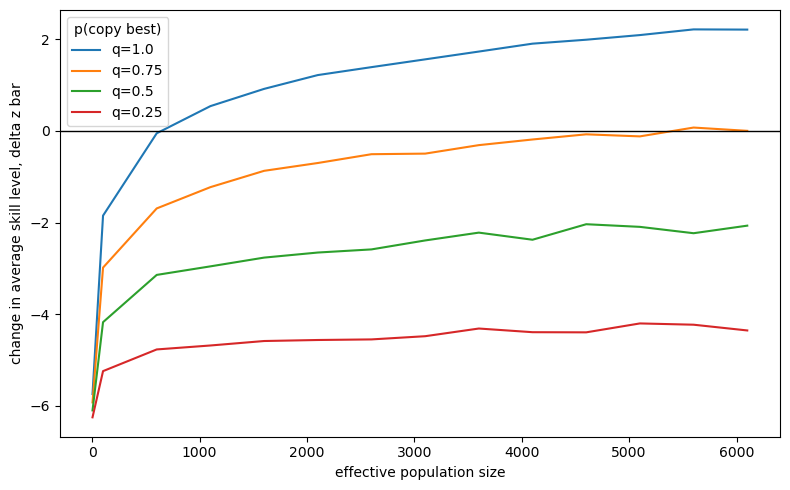

In [ ]:
def demography_model_prob(T_MAX, N, ALPHA, SIGMA, R_MAX, q=1.0):
    """
    Same as demography_model() but with a probabilistic learning rule.

    Parameters:
    - q: probability of imitating the best individual.
         With probability (1 - q), a random individual is chosen instead.
    """
    results = []

    for _ in range(R_MAX):
        z = np.ones(N)
        z_delta_bar = np.empty(T_MAX)

        for t in range(T_MAX):
            # Each individual picks their demonstrator
            #---------------------------------------------------#
            # Here, copy the best if random < q
            # Copy at random if random > q
            if np.random.rand() < q:
                # Copy the best individual
                demonstrator = z.max()
            else:
                # Copy a random individual
                demonstrator = np.random.choice(z)

            z_new = np.random.gumbel(
                loc=demonstrator - ALPHA,
                scale=SIGMA,
                size=N
            )
            z_delta_bar[t] = (z_new - z).mean()
            z = z_new

        results.append(z_delta_bar.mean())

    return np.mean(results)


# Sweep
sizes = np.concatenate(([2], np.arange(100, 6101, 500)))
qs = [1.0, 0.75, 0.5, 0.25]

plt.figure(figsize=(8, 5))

for q in qs:
    results = [
        demography_model_prob(T_MAX=200, N=N, ALPHA=7, SIGMA=1, R_MAX=20, q=q)
        for N in sizes
    ]
    plt.plot(sizes, results, label=f"q={q}")

plt.axhline(y=0, color="black", linewidth=1)
plt.xlabel("effective population size")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="p(copy best)")
plt.tight_layout()
plt.show()